# Faster Hybrid Strassen: Improvement over the Standard Version

## Aim
Compare four methods:

1. brute force;
2. standard recursive Strassen;
3. faster hybrid Strassen;
4. NumPy built-in multiplication `A @ B`.

## Mathematics
Both Strassen versions use the same seven products and satisfy

$$T(n)=7T(n/2)+\Theta(n^2).$$

The standard version uses brute force at a small cutoff. The hybrid version uses optimized `A @ B` at a larger cutoff:

$$T_H(n)=\begin{cases}
T_{@}(n), & n\le c,\\
7T_H(n/2)+\Theta(n^2), & n>c.
\end{cases}$$

Thus, the mathematics of the seven-product step is retained, but small matrix products are handled by an efficient compiled kernel.


## Before running the code

The code compares both Strassen versions on the same matrices. The first graph shows all methods. The second graph shows exactly how many times faster the hybrid implementation is than the standard implementation.


In [1]:
import time, statistics
import numpy as np
import matplotlib.pyplot as plt
SEED=20260907; SIZES=[8,16,32,64,128]; REPEATS=3; STANDARD_CUTOFF=8; HYBRID_CUTOFF=32
rng=np.random.default_rng(SEED)

def brute_force(A,B):
    n=A.shape[0]; C=np.zeros((n,n),dtype=A.dtype)
    for i in range(n):
        for j in range(n):
            for k in range(n): C[i,j] = C[i,j] + A[i,k]*B[k,j]
    return C

def strassen_core(A,B,cutoff,base):
    n=A.shape[0]
    if n<=cutoff: return base(A,B)
    h=n//2
    A11,A12,A21,A22=A[:h,:h],A[:h,h:],A[h:,:h],A[h:,h:]; B11,B12,B21,B22=B[:h,:h],B[:h,h:],B[h:,:h],B[h:,h:]
    M1=strassen_core(A11+A22,B11+B22,cutoff,base); M2=strassen_core(A21+A22,B11,cutoff,base)
    M3=strassen_core(A11,B12-B22,cutoff,base); M4=strassen_core(A22,B21-B11,cutoff,base)
    M5=strassen_core(A11+A12,B22,cutoff,base); M6=strassen_core(A21-A11,B11+B12,cutoff,base)
    M7=strassen_core(A12-A22,B21+B22,cutoff,base)
    C=np.empty((n,n),dtype=A.dtype)
    C[:h,:h]=M1+M4-M5+M7; C[:h,h:]=M3+M5; C[h:,:h]=M2+M4; C[h:,h:]=M1-M2+M3+M6
    return C

def standard_strassen(A,B): return strassen_core(A,B,STANDARD_CUTOFF,brute_force)
def hybrid_strassen(A,B): return strassen_core(A,B,HYBRID_CUTOFF,lambda X,Y:X@Y)

def mean_time(f,A,B,repeats=REPEATS):
    times=[]; C=None
    for _ in range(repeats): start=time.perf_counter(); C=f(A,B); times.append(time.perf_counter()-start)
    return statistics.mean(times),C


In [2]:
rows=[]
for n in SIZES:
    A=rng.integers(-5,6,(n,n),dtype=np.int64); B=rng.integers(-5,6,(n,n),dtype=np.int64)
    rb=1 if n>=64 else REPEATS
    tb,C1=mean_time(brute_force,A,B,rb); ts,C2=mean_time(standard_strassen,A,B); th,C3=mean_time(hybrid_strassen,A,B); tn,C4=mean_time(lambda X,Y:X@Y,A,B)
    assert np.array_equal(C1,C2) and np.array_equal(C1,C3) and np.array_equal(C1,C4)
    rows.append((n,tb,ts,th,tn)); print(f'n={n:3d}: brute={tb:.3e}, standard={ts:.3e}, hybrid={th:.3e}, built-in={tn:.3e}, improvement={ts/th:.2f}x')


n=  8: brute=2.943e-03, standard=1.423e-03, hybrid=2.034e-04, built-in=7.667e-06, improvement=7.00x
n= 16: brute=7.854e-03, standard=7.497e-03, hybrid=2.030e-05, built-in=1.380e-05, improvement=369.33x
n= 32: brute=5.988e-02, standard=5.050e-02, hybrid=1.521e-04, built-in=1.347e-04, improvement=332.02x
n= 64: brute=4.800e-01, standard=3.324e-01, hybrid=1.203e-03, built-in=1.405e-03, improvement=276.35x
n=128: brute=3.762e+00, standard=2.335e+00, hybrid=8.407e-03, built-in=1.076e-02, improvement=277.80x


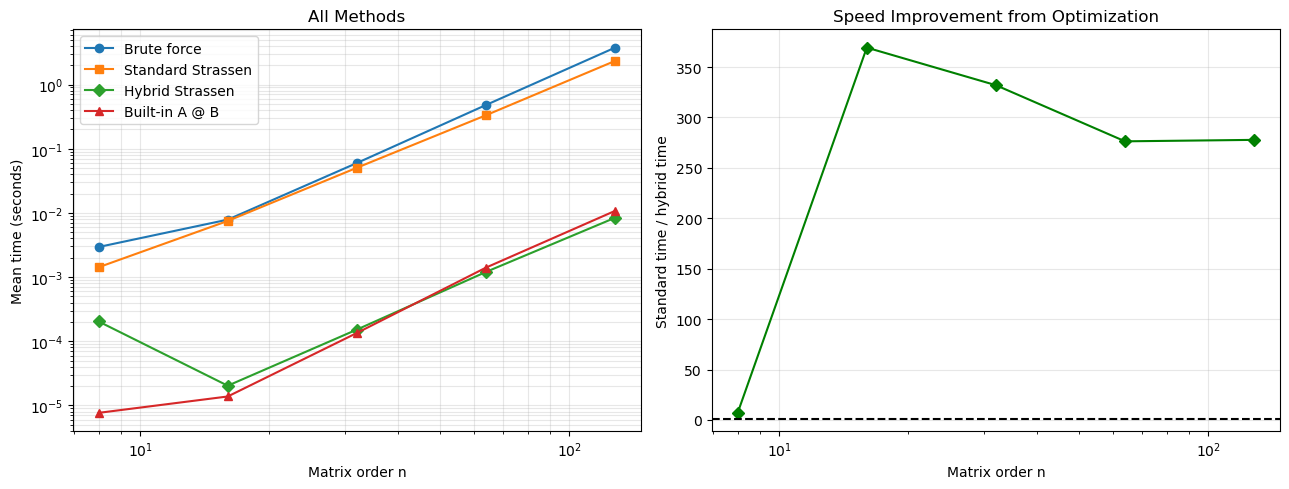

In [3]:
n=[r[0] for r in rows]; tb=[r[1] for r in rows]; ts=[r[2] for r in rows]; th=[r[3] for r in rows]; tn=[r[4] for r in rows]
fig,ax=plt.subplots(1,2,figsize=(13,5))
ax[0].loglog(n,tb,'o-',label='Brute force'); ax[0].loglog(n,ts,'s-',label='Standard Strassen'); ax[0].loglog(n,th,'D-',label='Hybrid Strassen'); ax[0].loglog(n,tn,'^-',label='Built-in A @ B')
ax[0].set(xlabel='Matrix order n',ylabel='Mean time (seconds)',title='All Methods'); ax[0].grid(True,which='both',alpha=.3); ax[0].legend()
improvement=[s/h for s,h in zip(ts,th)]
ax[1].semilogx(n,improvement,'D-',color='green'); ax[1].axhline(1,color='black',ls='--')
ax[1].set(xlabel='Matrix order n',ylabel='Standard time / hybrid time',title='Speed Improvement from Optimization'); ax[1].grid(True,alpha=.3)
plt.tight_layout(); plt.show()


### Meaning of the graphs

- The left graph compares brute force, standard Strassen, hybrid Strassen and built-in `A @ B` directly.
- In the right graph, $t_S/t_H=250$ means hybrid Strassen is 250 times as fast as standard Strassen.
- Values above $1$ show that the hybrid cutoff and built-in base kernel improved the implementation.
- Hybrid Strassen may still be slower than `A @ B` because it creates temporary block sums and performs recursive calls.


## Two exercises

### Exercise 1: Verify the base-case effect
For a $32\times32$ matrix pair, compare standard Strassen with cutoff 8 and hybrid Strassen with cutoff 32. Verify both answers using `A @ B`.

### Exercise 2: Plot improvement
For $n=16,32,64,128$, compute $t_S/t_H$. Plot the ratio and identify the matrix order giving the largest improvement.


In [2]:
n_ex1 = 32
A32 = rng.integers(-5, 6, (n_ex1, n_ex1), dtype=np.int64)
B32 = rng.integers(-5, 6, (n_ex1, n_ex1), dtype=np.int64)

ts_32, C_standard = mean_time(standard_strassen, A32, B32)
th_32, C_hybrid = mean_time(hybrid_strassen, A32, B32)
tn_32, C_builtin = mean_time(lambda X, Y: X @ Y, A32, B32)

# Verification using A @ B
assert np.array_equal(C_standard, C_builtin), "Standard Strassen mismatch!"
assert np.array_equal(C_hybrid, C_builtin), "Hybrid Strassen mismatch!"

print(f"32x32 Standard Strassen Time : {ts_32:.6e}s")
print(f"32x32 Hybrid Strassen Time   : {th_32:.6e}s")
print(f"Speedup Ratio (tS / tH)      : {ts_32 / th_32:.2f}x")
print("Verification with A @ B      : PASSED\n")

32x32 Standard Strassen Time : 1.451283e-02s
32x32 Hybrid Strassen Time   : 3.963333e-05s
Speedup Ratio (tS / tH)      : 366.18x
Verification with A @ B      : PASSED



n= 16 | standard=2.668533e-03s | hybrid=8.233333e-06s | tS/tH=324.11x
n= 32 | standard=1.225730e-02s | hybrid=1.546000e-04s | tS/tH=79.28x
n= 64 | standard=6.832847e-02s | hybrid=3.576667e-04s | tS/tH=191.04x
n=128 | standard=4.626214e-01s | hybrid=2.118233e-03s | tS/tH=218.40x

Largest improvement occurs at matrix order n = 16 with a ratio tS/tH = 324.11x


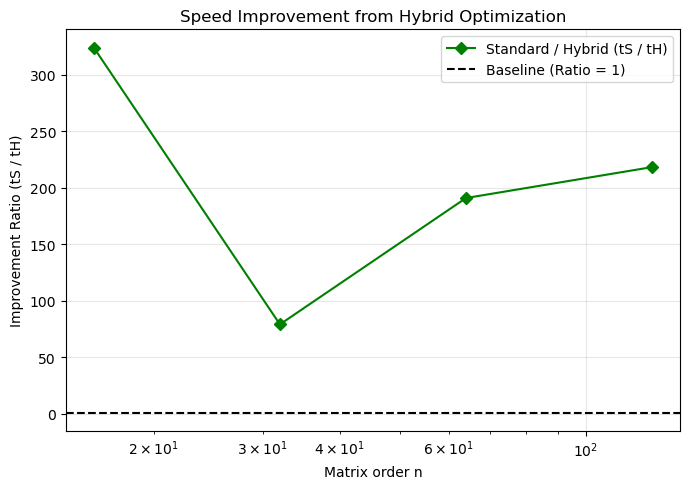

In [6]:
SIZES_EX2 = [16, 32, 64, 128]
rows = []

for n in SIZES_EX2:
    A = rng.integers(-5, 6, (n, n), dtype=np.int64)
    B = rng.integers(-5, 6, (n, n), dtype=np.int64)
    
    ts, C_std = mean_time(standard_strassen, A, B)
    th, C_hyb = mean_time(hybrid_strassen, A, B)
    assert np.array_equal(C_std, C_hyb)
    
    ratio = ts / th
    rows.append((n, ts, th, ratio))
    print(f'n={n:3d} | standard={ts:.6e}s | hybrid={th:.6e}s | tS/tH={ratio:.2f}x')

max_row = max(rows, key=lambda r: r[3])
print(f"\nLargest improvement occurs at matrix order n = {max_row[0]} with a ratio tS/tH = {max_row[3]:.2f}x")

n_vals = [r[0] for r in rows]
ratios = [r[3] for r in rows]

plt.figure(figsize=(7, 5))
plt.semilogx(n_vals, ratios, 'D-', color='green', label='Standard / Hybrid (tS / tH)')
plt.axhline(1, color='black', ls='--', label='Baseline (Ratio = 1)')

plt.xlabel('Matrix order n')
plt.ylabel('Improvement Ratio (tS / tH)')
plt.title('Speed Improvement from Hybrid Optimization')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()